In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
val = pd.read_parquet('data/val.parquet')

In [4]:
train.columns

Index(['Attack ID', 'Avg source IP count', 'Start time', 'End time', 'Type',
       'Detect count', 'Victim IP', 'Port number', 'Attack code',
       'Packet speed',
       ...
       'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH', 'PCA_1', 'PCA_2',
       'PCA_3', 'PCA_4', 'PCA_5'],
      dtype='object', length=130)

In [5]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5']

In [6]:
# KMeans clustering and optimal k selection
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Feature set
features = x_cols if 'x_cols' in globals() else train.select_dtypes(include=[np.number]).columns.drop('Type', errors='ignore').tolist()
print(f"Using {len(features)} features for clustering")

Using 123 features for clustering


Fitting k=10...
Fitting k=11...
Fitting k=12...
Fitting k=13...
Fitting k=14...
Fitting k=15...
Fitting k=16...
Fitting k=17...
Fitting k=18...
Fitting k=19...
Fitting k=20...
Fitting k=21...
Fitting k=22...
Fitting k=23...
Fitting k=24...
Fitting k=25...
Fitting k=26...
Fitting k=27...
Fitting k=28...
Fitting k=29...
Fitting k=30...
Fitting k=31...
Fitting k=32...
Fitting k=33...
Fitting k=34...
Fitting k=35...
Fitting k=36...
Fitting k=37...
Fitting k=38...
Fitting k=39...
Fitting k=40...
Fitting k=41...
Fitting k=42...
Fitting k=43...
Fitting k=44...
Fitting k=45...
Fitting k=46...
Fitting k=47...
Fitting k=48...
Fitting k=49...
Fitting k=50...
Fitting k=51...
Fitting k=52...
Fitting k=53...
Fitting k=54...
Fitting k=55...
Fitting k=56...
Fitting k=57...
Fitting k=58...
Fitting k=59...
Fitting k=60...
Fitting k=61...
Fitting k=62...
Fitting k=63...
Fitting k=64...
Fitting k=65...
Fitting k=66...
Fitting k=67...
Fitting k=68...
Fitting k=69...
Fitting k=70...
Fitting k=71...
Fitting 

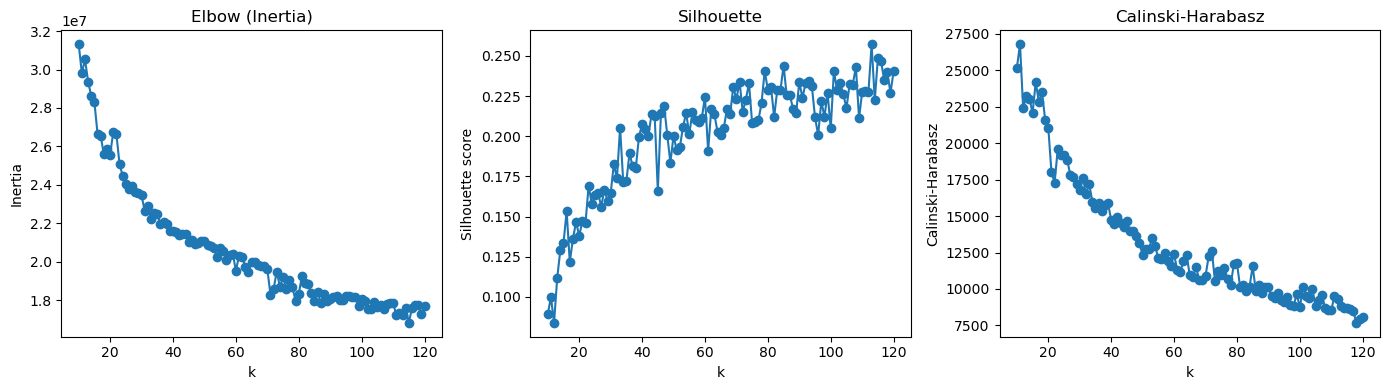

In [ ]:
# Subsample for search to keep memory/time reasonable
sample_frac = 0.3
rng = np.random.RandomState(42)
sample = train[features].sample(frac=sample_frac, random_state=rng)

# Scale
scaler = StandardScaler()
sample_scaled = scaler.fit_transform(sample)

# Range of k to try
k_min, k_max = 10, 120
ks = list(range(k_min, k_max + 1))

inertias = []
silhouettes = []
calinskis = []

# For silhouette, limit the number of samples used to compute it for speed
sil_sample_limit = 10000

for k in ks:
    print(f"Fitting k={k}...")
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096)
    mbk.fit(sample_scaled)
    labels = mbk.labels_
    inertias.append(mbk.inertia_)
    # compute silhouette on a random subset if large
    if sample_scaled.shape[0] > sil_sample_limit:
        idx = rng.choice(sample_scaled.shape[0], sil_sample_limit, replace=False)
        sil = silhouette_score(sample_scaled[idx], labels[idx])
    else:
        sil = silhouette_score(sample_scaled, labels)
    silhouettes.append(sil)
    calinskis.append(calinski_harabasz_score(sample_scaled, labels))

# Plot metrics
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(ks, inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow (Inertia)')

plt.subplot(1,3,2)
plt.plot(ks, silhouettes, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette')

plt.tight_layout()
plt.show()

In [8]:
# Pick best k by silhouette (you can choose another metric)
best_idx = int(np.argmax(silhouettes))
best_k = ks[best_idx] #112
print(f"Best k by silhouette: {best_k} (silhouette={silhouettes[best_idx]:.4f})")


Best k by silhouette: 113 (silhouette=0.2573)


In [12]:
X_train = train[features]
X_test = test[features]
X_val = val[features]

final_kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
final_kmeans.fit(X_train)
train['cluster'] = final_kmeans.labels_

final_kmeans.fit(X_test)
test['cluster'] = final_kmeans.labels_

final_kmeans.fit(X_val)
val['cluster'] = final_kmeans.labels_

# Calculate distances to centroids
train_dists = final_kmeans.transform(X_train)
test_dists = final_kmeans.transform(X_test)
val_dists = final_kmeans.transform(X_val)

# Add distances as features
dist_cols = [f'dist_centroid_{i}' for i in range(final_kmeans.n_clusters)]
train[dist_cols] = train_dists
test[dist_cols] = test_dists
val[dist_cols] = val_dists

print(f"Added {len(dist_cols)} distance features.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[dist_cols] = train_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[dist_cols] = train_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

Added 20 distance features.


C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val[dist_cols] = val_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val[dist_cols] = val_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\3442235408.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once 

In [10]:
X_train = train[features]
X_test = test[features]
X_val = val[features]

final_kmeans = KMeans(n_clusters=112, random_state=42, n_init=10)
final_kmeans.fit(X_train)

# Assign cluster labels (predict for test/val to maintain consistent centroids)
train['cluster112'] = final_kmeans.labels_
test['cluster112'] = final_kmeans.predict(X_test)
val['cluster112'] = final_kmeans.predict(X_val)

# Calculate distances to centroids
train_dists = final_kmeans.transform(X_train)
test_dists = final_kmeans.transform(X_test)
val_dists = final_kmeans.transform(X_val)

# Add distances as features
dist_cols = [f'dist_centroid_silhouette_{i}' for i in range(final_kmeans.n_clusters)]
train[dist_cols] = train_dists
test[dist_cols] = test_dists
val[dist_cols] = val_dists

print(f"Added {len(dist_cols)} distance features.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\1533262185.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[dist_cols] = train_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\1533262185.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[dist_cols] = train_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\1533262185.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

Added 112 distance features.


C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\1533262185.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val[dist_cols] = val_dists
C:\Users\Admin\AppData\Local\Temp\ipykernel_30744\1533262185.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val[dist_cols] = val_dists


In [14]:
train.to_parquet('data/train.parquet', index=False)
test.to_parquet('data/test.parquet', index=False)
val.to_parquet('data/val.parquet', index=False)

In [ ]:
for c in sorted(train['cluster'].unique()):
    print(f"Cluster {c}:")
    display(train.loc[train['cluster']==c, ['Attack code']].value_counts())
    display(train.loc[train['cluster']==c, ['Type']].value_counts())

Cluster 0:


Attack code                                     
High volume traffic                                 1716426
Suspicious traffic                                    45628
Generic UDP                                            9716
Suspicious traffic, DNS                                5325
Suspicious traffic, CLDAP                              4838
CLDAP, High volume traffic                             4308
ICMP                                                   3567
SYN Attack                                             2505
NTP                                                    2505
DNS, High volume traffic                               2090
Suspicious traffic, NTP                                1073
DNS                                                     782
CLDAP                                                   708
NTP, High volume traffic                                633
WSD                                                     554
DNS, CLDAP, High volume traffic                    

Type
1       1473214
0        264624
2         65906
Name: count, dtype: int64

Cluster 1:


Attack code                                                          
DNS, High volume traffic                                                 108
Suspicious traffic, DNS                                                  104
Suspicious traffic, DNS, WSD                                              85
Suspicious traffic, DNS, NTP, IPv4 fragmentation, WSD                     42
DNS, High volume traffic, WSD                                             40
Suspicious traffic, DNS, IPv4 fragmentation, WSD                          37
DNS, IPv4 fragmentation, High volume traffic, WSD                         36
Suspicious traffic, DNS, IPv4 fragmentation                               32
Suspicious traffic, DNS, NTP, WSD                                         26
DNS, IPv4 fragmentation, High volume traffic                              25
Suspicious traffic, DNS, NTP, RDP, WSD                                    23
Suspicious traffic, DNS, NTP, IPv4 fragmentation, RDP, WSD                13
Suspic

...

Attack code                                                     
High volume traffic, SYN Attack                                     104
DNS, IPv4 fragmentation, High volume traffic                         70
Suspicious traffic, DNS, IPv4 fragmentation                          27
DNS, High volume traffic, SYN Attack                                 25
Suspicious traffic, DNS, WSD                                         17
Suspicious traffic, DNS, NTP, CHARGEN, IPv4 fragmentation            15
Suspicious traffic, DNS, IPv4 fragmentation, WSD                     15
Suspicious traffic, SYN Attack                                       15
Suspicious traffic, DNS                                              13
Suspicious traffic, DNS, NTP, CHARGEN, IPv4 fragmentation, RDP       13
RPC, High volume traffic, SYN Attack                                 12
Suspicious traffic, DNS, NTP, IPv4 fragmentation                     10
DNS, High volume traffic                                             10

Type
0       458
Name: count, dtype: int64

Cluster 19:


Attack code                                                              
Suspicious traffic, DNS, NTP, IPv4 fragmentation                             60
DNS, NTP, High volume traffic, SYN Attack                                    30
Suspicious traffic, DNS, NTP, CHARGEN                                        28
Suspicious traffic, DNS, NTP, CHARGEN, IPv4 fragmentation, RDP               25
Suspicious traffic, DNS, NTP                                                 22
DNS, NTP, High volume traffic                                                16
Suspicious traffic, DNS, NTP, RDP                                             8
Suspicious traffic, DNS, NTP, CHARGEN, IPv4 fragmentation                     5
Suspicious traffic, DNS, NTP, CoAP, WSD                                       4
Suspicious traffic, DNS, NTP, IPv4 fragmentation, RDP                         4
DNS, NTP, Memcached, High volume traffic                                      3
DNS, NTP, CHARGEN, IPv4 fragmentation, High vo

Type
0       213
Name: count, dtype: int64

In [ ]:
for c in sorted(test['cluster112'].unique()):       
    print(f"Cluster {c}:")
    display(test.loc[test['cluster112']==c, ['Type']].value_counts())
    display(train.loc[train['cluster']==c, ['Attack code']].value_counts())

Cluster 0:


Type
1       443728
0        76877
2        19722
Name: count, dtype: int64

Attack code                                     
High volume traffic                                 1716426
Suspicious traffic                                    45628
Generic UDP                                            9716
Suspicious traffic, DNS                                5325
Suspicious traffic, CLDAP                              4838
CLDAP, High volume traffic                             4308
ICMP                                                   3567
SYN Attack                                             2505
NTP                                                    2505
DNS, High volume traffic                               2090
Suspicious traffic, NTP                                1073
DNS                                                     782
CLDAP                                                   708
NTP, High volume traffic                                633
WSD                                                     554
DNS, CLDAP, High volume traffic                    

Cluster 1:


Type
0       33
Name: count, dtype: int64

...

Type
0       1
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

Cluster 111:


Type
0       3017
1        213
2         12
Name: count, dtype: int64

Series([], Name: count, dtype: int64)